<a href="https://colab.research.google.com/github/shafiqul-cyber/Skill_Morph_Practice_from_Instrictor-/blob/Skill_Morph/Assignment_9_Ransomware_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Detection cloud DDos**

## **Font family setup**

In [ ]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [ ]:
#Dataset Link: https://www.kaggle.com/datasets/bcccdatasets/bccc-cpacket-cloud-ddos-2024

## **Mount Gdrive**

In [ ]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Access the file in Google Drive
Original_Dataset = pd.read_csv("/content/drive/MyDrive/skill_morph/Network_security/new_dataset/merged_CSVs.csv")

/tmp/ipython-input-1494091421.py:2: DtypeWarning: Columns (3,5,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,2

In [ ]:
Original_Dataset.head()

,flow_id,timestamp,src_ip,src_port,dst_ip,dst_port,protocol,duration,packets_count,fwd_packets_count,...,max_fwd_payload_bytes_delta_len,mean_fwd_payload_bytes_delta_len,mode_fwd_payload_bytes_delta_len,variance_fwd_payload_bytes_delta_len,std_fwd_payload_bytes_delta_len,median_fwd_payload_bytes_delta_len,skewness_fwd_payload_bytes_delta_len,cov_fwd_payload_bytes_delta_len,label,activity
0,35.203.211.133_54573_10.0.4.57_25094_TCP_2023-...,2023-12-14 09:01:03.508091,35.203.211.133,54573,10.0.4.57,25094,TCP,0.000063,3,2,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,Benign,Benign
1,10.0.4.57_25094_35.203.211.133_54573_TCP_2023-...,2023-12-14 09:01:03.508156,10.0.4.57,25094,35.203.211.133,54573,TCP,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
2,35.203.211.133_54573_10.0.4.57_25094_TCP_2023-...,2023-12-14 09:01:03.508431,35.203.211.133,54573,10.0.4.57,25094,TCP,0.000028,3,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
3,162.142.125.181_9147_10.0.4.57_18060_TCP_2023-...,2023-12-14 09:01:06.696817,162.142.125.181,9147,10.0.4.57,18060,TCP,0.000055,3,2,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,Benign,Benign
4,10.0.4.57_18060_162.142.125.181_9147_TCP_2023-...,2023-12-14 09:01:06.696874,10.0.4.57,18060,162.142.125.181,9147,TCP,0.0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign


In [ ]:
Original_Dataset.describe()

,flow_id,timestamp,src_ip,src_port,dst_ip,dst_port,protocol,duration,packets_count,fwd_packets_count,...,max_fwd_payload_bytes_delta_len,mean_fwd_payload_bytes_delta_len,mode_fwd_payload_bytes_delta_len,variance_fwd_payload_bytes_delta_len,std_fwd_payload_bytes_delta_len,median_fwd_payload_bytes_delta_len,skewness_fwd_payload_bytes_delta_len,cov_fwd_payload_bytes_delta_len,label,activity
count,700776,700774,700776,700776,700776,700776,700776,700776.0,700776,700776,...,700776.0,700776.0,700776.0,700776.0,700776.0,700776.0,620038.0,620626.0,700776,700776
unique,699995,695034,11345,59864,5091,67976,2,174915.0,1784,1336,...,1244.0,1244.0,524.0,15009.0,14978.0,374.0,7306.0,3559.0,4,27
top,10.0.3.52_50367_172.64.80.1_443_TCP_2023-12-19...,2023-12-19 10:50:08.590068,130.63.226.46,42048,10.0.6.142,3389,TCP,0.0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
freq,6,6,131094,100379,141753,77409,700774,329003.0,328762,393447,...,538210.0,687558.0,592468.0,538623.0,538623.0,597911.0,463632.0,458965.0,413199,302284


# ***Due to colab RAM Memory shortage I have used Kaggle for all the preprocessing steps***

In [ ]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/skill_morph/Network_security/new_dataset/Final_my_processed_data.csv")

In [ ]:
df['label'].value_counts()

,count
label,
Benign,346334
Attack,169977
Suspicious,20356


In [ ]:
df.head()

,flow_id,timestamp,src_ip,src_port,dst_ip,dst_port,protocol,duration,packets_count,fwd_packets_count,...,max_fwd_payload_bytes_delta_len,mean_fwd_payload_bytes_delta_len,mode_fwd_payload_bytes_delta_len,variance_fwd_payload_bytes_delta_len,std_fwd_payload_bytes_delta_len,median_fwd_payload_bytes_delta_len,skewness_fwd_payload_bytes_delta_len,cov_fwd_payload_bytes_delta_len,label,activity
0,417876,2,7955,0.778982,9,0.019498,0,-0.021452,0.000875,0.002473,...,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Benign,17
1,53766,3,43,-1.080125,3246,1.431747,0,-0.021459,-0.002683,-0.007316,...,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Benign,17
2,417877,4,7955,0.778982,9,0.019498,0,-0.021456,0.000875,-0.002421,...,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Benign,17
3,233482,7,2701,-2.085831,9,-0.317479,0,-0.021453,0.000875,0.002473,...,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Benign,17
4,51516,8,43,-1.523728,712,-0.744474,0,-0.021459,-0.002683,-0.007316,...,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Benign,17


# ***For testing the dataset result i have used 10% data first to check the result ***

# ***Stratified 10% by a label column (keeps class balance)***

In [ ]:
# Replace 'label' with your target column name
df_10 = (
    df.groupby('label', group_keys=False)
      .apply(lambda x: x.sample(frac=0.10, random_state=42))
)


/tmp/ipython-input-2530764039.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.10, random_state=42))


In [ ]:
df_10['label'].value_counts()

,count
label,
Benign,34633
Attack,16998
Suspicious,2036


In [ ]:
df_10.head()

,flow_id,timestamp,src_ip,src_port,dst_ip,dst_port,protocol,duration,packets_count,fwd_packets_count,...,max_fwd_payload_bytes_delta_len,mean_fwd_payload_bytes_delta_len,mode_fwd_payload_bytes_delta_len,variance_fwd_payload_bytes_delta_len,std_fwd_payload_bytes_delta_len,median_fwd_payload_bytes_delta_len,skewness_fwd_payload_bytes_delta_len,cov_fwd_payload_bytes_delta_len,label,activity
300800,181639,299662,1925,0.825209,10,-0.064051,0,-0.021459,-0.002683,-0.002421,...,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Attack,2
297902,164663,296903,1925,0.590731,10,1.271163,0,-0.021459,-0.002683,-0.002421,...,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Attack,2
385463,172471,381233,1925,0.697312,10,1.687618,0,-0.021459,-0.002683,-0.002421,...,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Attack,2
396707,206721,392060,1925,1.166519,10,-0.669595,0,-0.021459,-0.002683,-0.002421,...,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Attack,2
324017,87909,322103,1925,-0.450354,10,1.825973,0,-0.021459,-0.002683,-0.002421,...,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Attack,2


## **Due to the shortage of  RAM space in colab, all the preproccessing steps will be done by kaggle environment. thats why we start here from splitting.**

Pre-proccessing steps involved.
1. missing value handling
2. normalization(encoding) etc


## **Basic Information**

In [ ]:
df

,src_port,dst_port,protocol,duration,packets_count,fwd_packets_count,bwd_packets_count,total_payload_bytes,fwd_total_payload_bytes,bwd_total_payload_bytes,...,min_fwd_payload_bytes_delta_len,max_fwd_payload_bytes_delta_len,mean_fwd_payload_bytes_delta_len,mode_fwd_payload_bytes_delta_len,variance_fwd_payload_bytes_delta_len,std_fwd_payload_bytes_delta_len,median_fwd_payload_bytes_delta_len,skewness_fwd_payload_bytes_delta_len,cov_fwd_payload_bytes_delta_len,label
0,0.778982,0.019498,0,-0.021452,0.000875,0.002473,-0.000037,-0.002778,-0.002322,-0.001751,...,0.030903,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Benign
1,-1.080125,1.431747,0,-0.021459,-0.002683,-0.007316,-0.000037,-0.002778,-0.002322,-0.001751,...,0.030903,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Benign
2,0.778982,0.019498,0,-0.021456,0.000875,-0.002421,0.002755,-0.002778,-0.002322,-0.001751,...,0.030903,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Benign
3,-2.085831,-0.317479,0,-0.021453,0.000875,0.002473,-0.000037,-0.002778,-0.002322,-0.001751,...,0.030903,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Benign
4,-1.523728,-0.744474,0,-0.021459,-0.002683,-0.007316,-0.000037,-0.002778,-0.002322,-0.001751,...,0.030903,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536662,0.834732,-1.020465,0,-0.021438,-0.000904,-0.002421,-0.000037,-0.002778,-0.002322,-0.001751,...,0.030903,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Benign
536663,0.638094,1.002740,0,-0.021447,-0.000904,-0.002421,-0.000037,-0.002778,-0.002322,-0.001751,...,0.030903,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Benign
536664,0.596849,1.240407,0,-0.021459,-0.002683,-0.002421,-0.002830,-0.002778,-0.002322,-0.001751,...,0.030903,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Benign
536665,0.396553,0.291658,0,-0.021459,-0.002683,-0.002421,-0.002830,-0.002778,-0.002322,-0.001751,...,0.030903,-0.023856,0.010302,0.029049,-0.0259,-0.031606,0.007936,0.002635,278,Suspicious


In [ ]:
df.shape

(536667, 324)

In [ ]:
df['label'].value_counts()

,count
label,
Benign,346334
Attack,169977
Suspicious,20356


## **Data Samples per Class**

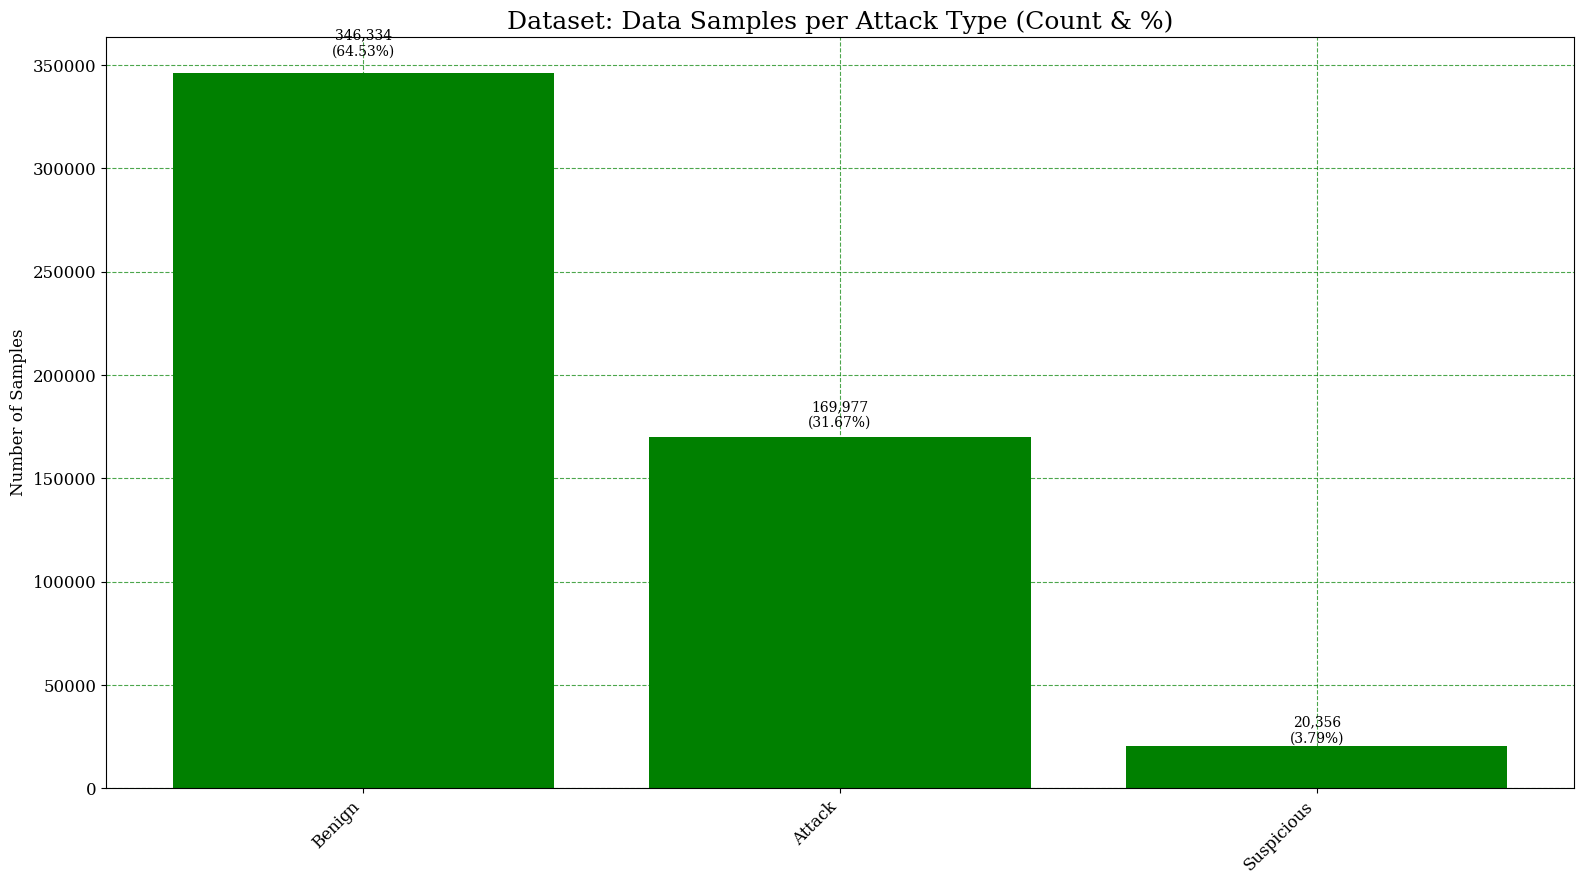

In [ ]:
import matplotlib.pyplot as plt

# Count samples and percentages
label_counts = df['label'].value_counts()
label_percentages = (label_counts / label_counts.sum()) * 100

# Set up the plot
plt.figure(figsize=(16, 9))
bars = plt.bar(label_counts.index, label_counts.values, color='green')  # Bar color set to green

# Add count and percentage text above each bar
for idx, bar in enumerate(bars):
    height = bar.get_height()
    count_text = f'{label_counts.values[idx]:,}'
    percent_text = f'({label_percentages.values[idx]:.2f}%)'

    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.02*height,
        f'{count_text}\n{percent_text}',
        ha='center', va='bottom', fontsize=10
    )

# Titles and labels
plt.title('Dataset: Data Samples per Attack Type (Count & %)', fontsize=18)
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.7, color='green')  # Grid color set to green
# Enable both horizontal and vertical green grid lines
plt.grid(axis='both', linestyle='--', alpha=0.7, color='green')

plt.tight_layout()

# Show plot
plt.show()


## **Handle Missing Values**

In [ ]:
# Print the names of the features (columns)
print(df.columns)

## **Data Preprocessing**

## **After Processing**

In [ ]:
df['label'].value_counts()

,count
label,
Benign,346334
Attack,169977
Suspicious,20356


In [ ]:
####Copy the processed df to different df

df1 = df.copy()
df2 = df.copy()

# **Binary Class (Anomaly) Classification**

In [ ]:
df1['label'] = df1['label'].apply(lambda x: 'Benign' if x == 'Benign' else 'Ransomware')

In [ ]:
# Check counts
print(df1['label'].value_counts())

label
Benign        346334
Ransomware    190333
Name: count, dtype: int64


In [ ]:
# Define label and feature columns
X = df1.drop(columns=['label'])
y = df1['label']

## **Traing and Test Division**

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (429333, 323)
X_test shape:  (107334, 323)
y_train shape: (429333,)
y_test shape:  (107334,)


## **Train & Evaluate Random Forest Classifier**

Accuracy:  0.99887
Precision: 0.99887
Recall:    0.99887
F1 Score:  0.99887


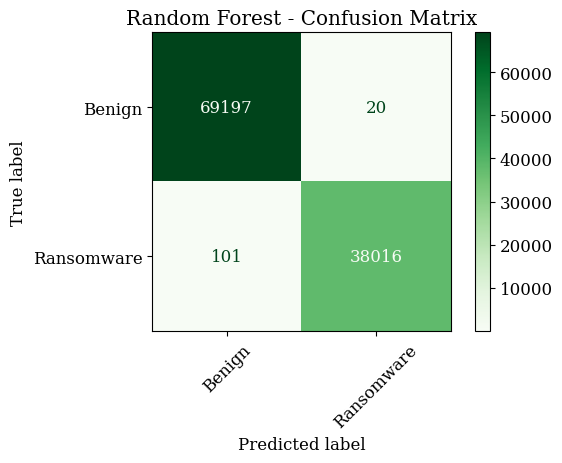

Classification Report:
              precision    recall  f1-score   support

      Benign    0.99854   0.99971   0.99913     69217
  Ransomware    0.99947   0.99735   0.99841     38117

    accuracy                        0.99887    107334
   macro avg    0.99901   0.99853   0.99877    107334
weighted avg    0.99887   0.99887   0.99887    107334



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(
    cmap='Greens', xticks_rotation=45
)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))


In [ ]:
# === 7) Save the trained model and artifacts ===
import os, json, joblib
from datetime import datetime

# Create a folder to keep your model files (adjust this if using Google Drive)
MODEL_DIR = "/content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17"
os.makedirs(MODEL_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
model_path = os.path.join(MODEL_DIR, f"rf_model_{timestamp}.joblib")
labels_path = os.path.join(MODEL_DIR, f"rf_labels_{timestamp}.json")
metrics_path = os.path.join(MODEL_DIR, f"rf_metrics_{timestamp}.json")
report_path = os.path.join(MODEL_DIR, f"rf_clf_report_{timestamp}.txt")
cmfig_path = os.path.join(MODEL_DIR, f"rf_confusion_matrix_{timestamp}.png")

# 7a) Save the fitted model (use joblib for sklearn)
joblib.dump(rf_model, model_path)

# 7b) Save label names (handy when you reload the model)
class_names = list(rf_model.classes_)
with open(labels_path, "w") as f:
    json.dump({"classes": class_names}, f, indent=2)

# 7c) Save metrics + classification report for reference
metrics = {
    "accuracy": float(accuracy),
    "precision_weighted": float(precision),
    "recall_weighted": float(recall),
    "f1_weighted": float(f1),
    "n_test_samples": int(len(y_test))
}
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

from sklearn.metrics import classification_report as cr_
with open(report_path, "w") as f:
    f.write(cr_(y_test, y_pred, zero_division=0, digits=5))

# 7d) Save the confusion matrix plot image too
plt.savefig(cmfig_path, dpi=300)

print(f"\nSaved model to: {model_path}")
print(f"Saved class labels to: {labels_path}")
print(f"Saved metrics to: {metrics_path}")
print(f"Saved report to: {report_path}")
print(f"Saved confusion matrix figure to: {cmfig_path}")

# === 8) (Optional) Save feature names if X_train is a DataFrame ===
try:
    feature_names = list(X_train.columns)
    feat_path = os.path.join(MODEL_DIR, f"rf_features_{timestamp}.json")
    with open(feat_path, "w") as f:
        json.dump({"features": feature_names}, f, indent=2)
    print(f"Saved feature names to: {feat_path}")
except Exception:
    pass



Saved model to: /content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/rf_model_20251022-071112.joblib
Saved class labels to: /content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/rf_labels_20251022-071112.json
Saved metrics to: /content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/rf_metrics_20251022-071112.json
Saved report to: /content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/rf_clf_report_20251022-071112.txt
Saved confusion matrix figure to: /content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/rf_confusion_matrix_20251022-071112.png
Saved feature names to: /content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/rf_features_20251022-071112.json


<Figure size 640x480 with 0 Axes>

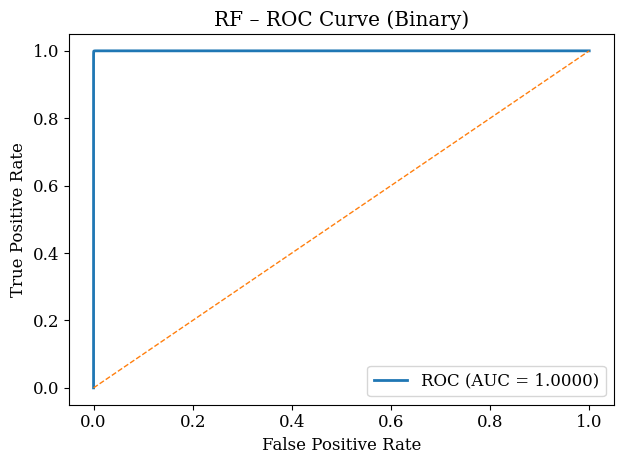

ROC-AUC (binary): 1.00000


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# --- AUC / ROC ---
classes = rf_model.classes_
is_multiclass = len(classes) > 2

# KNN supports predict_proba
y_score = rf_model.predict_proba(X_test)

if not is_multiclass:
    # Binary case
    # Choose the positive label explicitly to avoid ambiguity
    pos_label = classes[1]  # assumes classes are ordered [negative, positive]
    fpr, tpr, _ = roc_curve(y_test, y_score[:, 1], pos_label=pos_label)
    auc_val = roc_auc_score(y_test, y_score[:, 1])

    plt.figure()
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC (AUC = {auc_val:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("RF – ROC Curve (Binary)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"ROC-AUC (binary): {auc_val:.5f}")

else:
    # Multiclass (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=classes)  # shape (n_samples, n_classes)

    # Per-class ROC & AUC
    fpr, tpr, aucs = dict(), dict(), dict()
    for i, cls in enumerate(classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        aucs[i] = roc_auc_score(y_test_bin[:, i], y_score[:, i])

    # Micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    aucs["micro"] = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")

    # Macro-average (mean of per-class AUCs)
    aucs["macro"] = np.mean([aucs[i] for i in range(len(classes))])

    # Plot
    plt.figure()
    # plot micro first
    plt.plot(fpr["micro"], tpr["micro"], linewidth=2, label=f"micro-average ROC (AUC = {aucs['micro']:.4f})")
    # plot each class
    for i, cls in enumerate(classes):
        plt.plot(fpr[i], tpr[i], linewidth=1.5, label=f"Class {cls} (AUC = {aucs[i]:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("KNN – ROC Curves (Multiclass OvR)")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

    print(f"ROC-AUC (micro): {aucs['micro']:.5f}")
    print(f"ROC-AUC (macro): {aucs['macro']:.5f}")
    for i, cls in enumerate(classes):
        print(f"ROC-AUC (class {cls} vs rest): {aucs[i]:.5f}")


## **Explainable AI (XAI)**

### **LIME (Local Interpretable Model-Agnostic Explanations)**

In [ ]:
!pip install lime

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
from lime import lime_tabular
import numpy as np

# Initialize explainer
explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Benign', 'Ransomeware'],  # or use list(model.classes_) if applicable
    mode='classification'
)

# Explain one sample (you can change index)
sample_index = 10
exp = explainer.explain_instance(
    data_row=X_test.iloc[sample_index],
    predict_fn=rf_model.predict_proba
)

# Show explanation
exp.show_in_notebook(show_table=True)


# **Multiclass Classification**

In [ ]:
# Define label and feature columns
X = df2.drop(columns=['label'])
y = df2['label']

## **Traing and Test Division**

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y              # Ensures class distribution is preserved
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (429333, 323)
X_test shape:  (107334, 323)
y_train shape: (429333,)
y_test shape:  (107334,)


## **Train & Evaluate Random Forest Classifier**

Accuracy:  0.99843
Precision: 0.99843
Recall:    0.99843
F1 Score:  0.99843


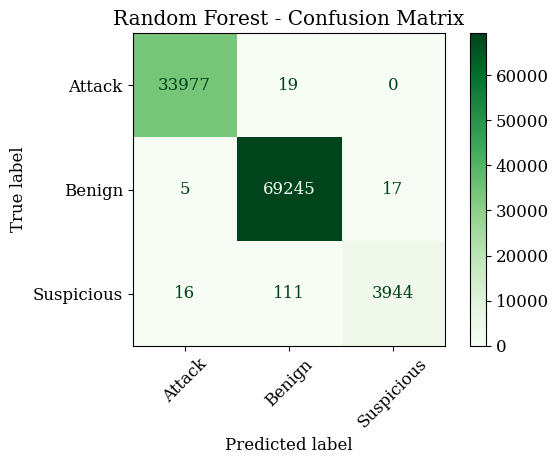

Classification Report:
              precision    recall  f1-score   support

      Attack    0.99938   0.99944   0.99941     33996
      Benign    0.99813   0.99968   0.99890     69267
  Suspicious    0.99571   0.96880   0.98207      4071

    accuracy                        0.99843    107334
   macro avg    0.99774   0.98931   0.99346    107334
weighted avg    0.99843   0.99843   0.99843    107334



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(
    cmap='Greens', xticks_rotation=45
)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))


In [ ]:
# === 7) Save the trained model and artifacts ===
import os, json, joblib
from datetime import datetime

# Create a folder to keep your model files (adjust this if using Google Drive)
MODEL_DIR = "/content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/Multi_Model"
os.makedirs(MODEL_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
model_path = os.path.join(MODEL_DIR, f"rf_model_{timestamp}.joblib")
labels_path = os.path.join(MODEL_DIR, f"rf_labels_{timestamp}.json")
metrics_path = os.path.join(MODEL_DIR, f"rf_metrics_{timestamp}.json")
report_path = os.path.join(MODEL_DIR, f"rf_clf_report_{timestamp}.txt")
cmfig_path = os.path.join(MODEL_DIR, f"rf_confusion_matrix_{timestamp}.png")

# 7a) Save the fitted model (use joblib for sklearn)
joblib.dump(rf_model, model_path)

# 7b) Save label names (handy when you reload the model)
class_names = list(rf_model.classes_)
with open(labels_path, "w") as f:
    json.dump({"classes": class_names}, f, indent=2)

# 7c) Save metrics + classification report for reference
metrics = {
    "accuracy": float(accuracy),
    "precision_weighted": float(precision),
    "recall_weighted": float(recall),
    "f1_weighted": float(f1),
    "n_test_samples": int(len(y_test))
}
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

from sklearn.metrics import classification_report as cr_
with open(report_path, "w") as f:
    f.write(cr_(y_test, y_pred, zero_division=0, digits=5))

# 7d) Save the confusion matrix plot image too
plt.savefig(cmfig_path, dpi=300)

print(f"\nSaved model to: {model_path}")
print(f"Saved class labels to: {labels_path}")
print(f"Saved metrics to: {metrics_path}")
print(f"Saved report to: {report_path}")
print(f"Saved confusion matrix figure to: {cmfig_path}")

# === 8) (Optional) Save feature names if X_train is a DataFrame ===
try:
    feature_names = list(X_train.columns)
    feat_path = os.path.join(MODEL_DIR, f"rf_features_{timestamp}.json")
    with open(feat_path, "w") as f:
        json.dump({"features": feature_names}, f, indent=2)
    print(f"Saved feature names to: {feat_path}")
except Exception:
    pass



Saved model to: /content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/Multi_Model/rf_model_20251022-072846.joblib
Saved class labels to: /content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/Multi_Model/rf_labels_20251022-072846.json
Saved metrics to: /content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/Multi_Model/rf_metrics_20251022-072846.json
Saved report to: /content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/Multi_Model/rf_clf_report_20251022-072846.txt
Saved confusion matrix figure to: /content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/Multi_Model/rf_confusion_matrix_20251022-072846.png
Saved feature names to: /content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/Multi_Model/rf_features_20251022-072846.json


<Figure size 640x480 with 0 Axes>

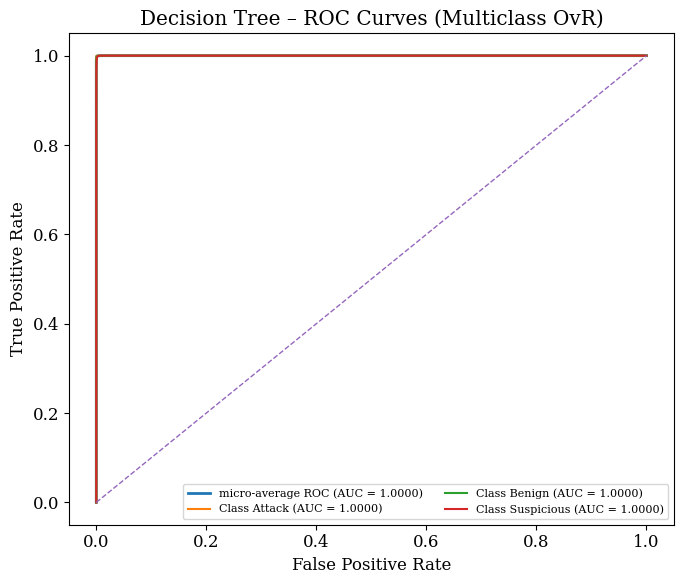

ROC-AUC (micro): 0.99999
ROC-AUC (macro): 0.99999
ROC-AUC (class Attack vs rest): 1.00000
ROC-AUC (class Benign vs rest): 0.99999
ROC-AUC (class Suspicious vs rest): 0.99997


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# --- Multiclass ROC / AUC for Decision Tree ---
# Uses predict_proba (available for DecisionTreeClassifier)
classes = rf_model.classes_
y_score = rf_model.predict_proba(X_test)   # shape: (n_samples, n_classes)

# Binarize true labels to one-vs-rest format
y_test_bin = label_binarize(y_test, classes=classes)  # shape: (n_samples, n_classes)

# Compute per-class ROC and AUC
fpr, tpr, aucs = {}, {}, {}
for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    aucs[i] = roc_auc_score(y_test_bin[:, i], y_score[:, i])

# Micro-average ROC/AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
aucs["micro"] = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")

# Macro-average AUC (mean of per-class AUCs)
aucs["macro"] = float(np.mean([aucs[i] for i in range(len(classes))]))

# ---- Plot ROC curves ----
plt.figure(figsize=(7, 6))

# Micro-average first
plt.plot(fpr["micro"], tpr["micro"], linewidth=2,
         label=f"micro-average ROC (AUC = {aucs['micro']:.4f})")

# Per-class curves
for i, cls in enumerate(classes):
    plt.plot(fpr[i], tpr[i], linewidth=1.5,
             label=f"Class {cls} (AUC = {aucs[i]:.4f})")

# Diagonal reference
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree – ROC Curves (Multiclass OvR)")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

# ---- Print AUCs ----
print(f"ROC-AUC (micro): {aucs['micro']:.5f}")
print(f"ROC-AUC (macro): {aucs['macro']:.5f}")
for i, cls in enumerate(classes):
    print(f"ROC-AUC (class {cls} vs rest): {aucs[i]:.5f}")


In [ ]:

# ==== 1) Point to your saved model in Drive ====
MODEL_PATH = "/content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/Multi_Model/rf_model_20251022-072846.joblib"  # <- change this

import joblib, os, json
rf_model = joblib.load(MODEL_PATH)
print("Loaded model:", type(rf_model))
print("Classes:", getattr(rf_model, "classes_", None))

# (Optional) If you also saved feature names:
FEATURES_JSON = "/content/drive/MyDrive/skill_morph/Network_security/new_dataset/results_2025-10-18_05-59-17/Multi_Model/rf_features_20251022-072846.json"  # <- change if exists
feature_names_saved = None
if os.path.exists(FEATURES_JSON):
    with open(FEATURES_JSON, "r") as f:
        feature_names_saved = json.load(f).get("features")


Loaded model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Classes: ['Attack' 'Benign' 'Suspicious']


In [ ]:
# ==== 2) Prepare background data for LIME ====
# Use your TRAIN distribution for best results
import numpy as np
import pandas as pd

# Assume X_train, X_test, y_test already loaded in your notebook.
# If you only have X_test handy, you can use that (less ideal but works).
X_bg = X_train if 'X_train' in globals() else X_test

if isinstance(X_bg, pd.DataFrame):
    feature_names = list(X_bg.columns)
    X_bg_np = X_bg.values
else:
    feature_names = feature_names_saved or [f"f{i}" for i in range(np.asarray(X_bg).shape[1])]
    X_bg_np = np.asarray(X_bg)


In [ ]:
# ==== 3) LIME explainer & explanation (3 classes) ====
from lime import lime_tabular

class_names = list(getattr(rf_model, "classes_", ["Attack","Benign","Suspicious"]))

explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_bg_np,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    discretize_continuous=True
)

sample_index = 10
x0 = X_test.iloc[sample_index] if hasattr(X_test, "iloc") else X_test[sample_index]
x0_np = np.array(x0)

exp = explainer.explain_instance(
    data_row=x0_np,
    predict_fn=lambda X: rf_model.predict_proba(X),
    num_features=10,
    top_labels=3
)

# Show in notebook (uncomment if desired)
# exp.show_in_notebook(show_table=True)

# Save the HTML directly into Drive
HTML_OUT = "/content/drive/MyDrive/skill_morph/Network_security/Best_Model_Random_Forest/lime_explanation_sample10.html"
with open(HTML_OUT, "w", encoding="utf-8") as f:
    f.write(exp.as_html())
print("Saved LIME HTML to:", HTML_OUT)


Saved LIME HTML to: /content/drive/MyDrive/skill_morph/Network_security/Best_Model_Random_Forest/lime_explanation_sample10.html


In [ ]:
# 1) Save LIME to HTML first
html_path = "lime_explanation_sample10.html"
with open(html_path, "w", encoding="utf-8") as f:
    f.write(exp.as_html())
print("Saved:", html_path)


Saved: lime_explanation_sample10.html


# **Modified Confusion Matrix**

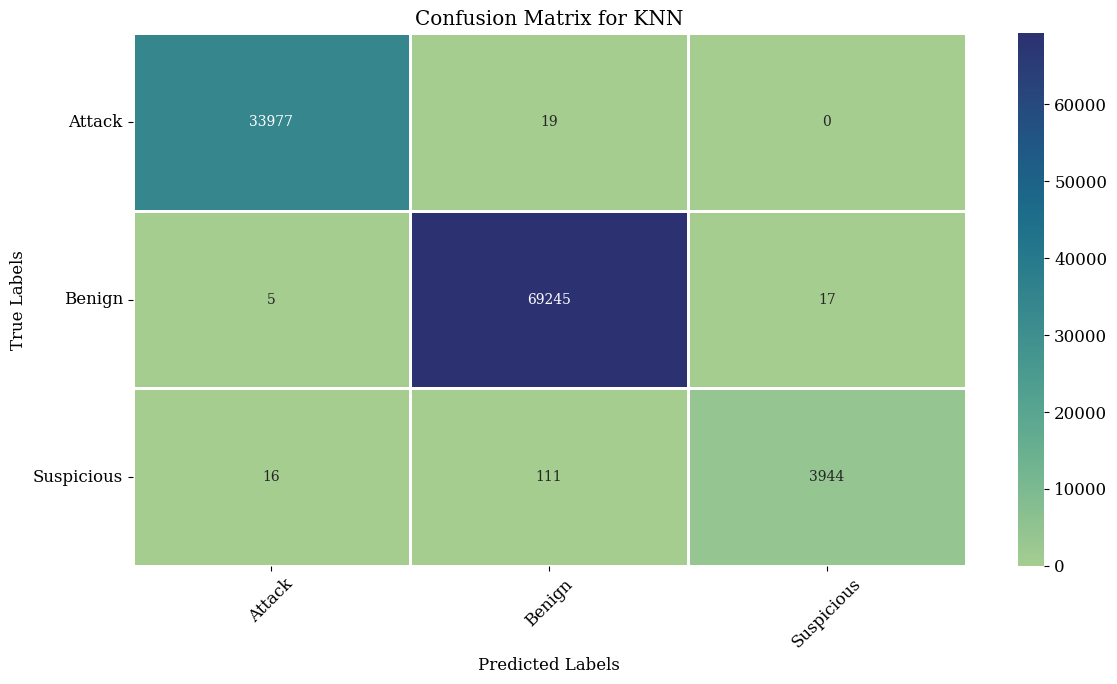

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Colormap
cmap = sns.color_palette("crest", as_cmap=True)

# Automatically get class labels from model
class_labels = rf_model.classes_

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Plot CM
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
            ax=ax, annot_kws={"fontsize": 10}, linewidths=1, linecolor='white')

ax.set_title("Confusion Matrix for KNN")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()


# **Features Calculation!**

Top feature importances (Random Forest):


,Rank,Feature,Importance
0,1,activity,0.182942
1,2,median_header_bytes,0.115001
2,3,fwd_mode_header_bytes,0.072020
3,4,fwd_min_header_bytes,0.070916
4,5,packets_IAT_mean,0.068717
5,6,packets_IAT_mode,0.055849
6,7,mode_header_bytes,0.048515
7,8,fwd_packets_IAT_min,0.043358
8,9,max_header_bytes,0.037929
9,10,mean_bwd_packets_delta_len,0.021506


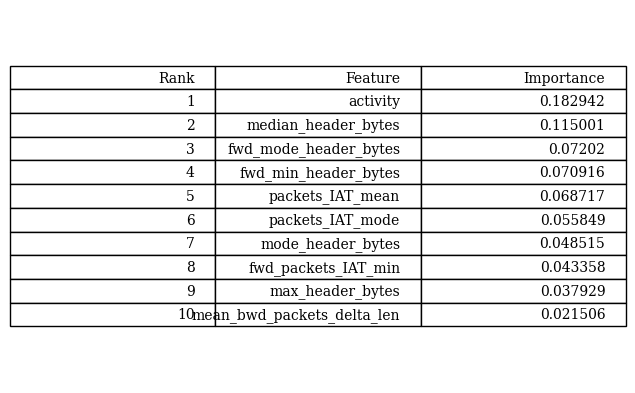

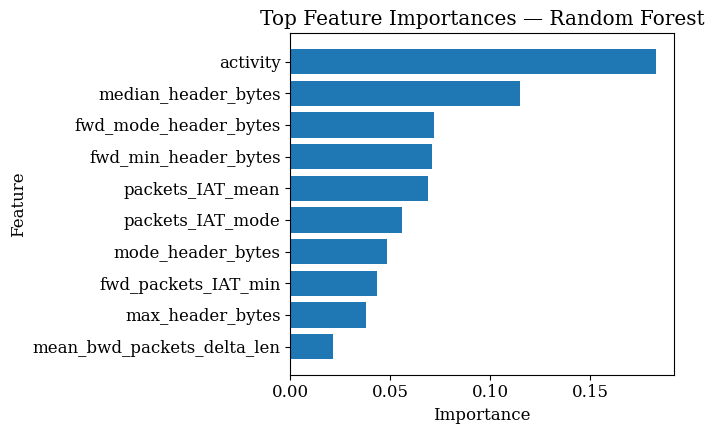

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from sklearn.ensemble import RandomForestClassifier

# ===== 0) Train RF (skip if already trained) =====
try:
    rf_model
except NameError:
    rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)

# ===== 1) Feature names =====
if hasattr(X_train, "columns"):
    feature_names = X_train.columns.tolist()
else:
    feature_names = [f"f{i}" for i in range(X_train.shape[1])]

# ===== 2) Importances, ranking =====
importances = rf_model.feature_importances_
imp_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
imp_df = imp_df.sort_values("Importance", ascending=False).reset_index(drop=True)
imp_df["Rank"] = np.arange(1, len(imp_df) + 1)

TOP_K = 10
topk = imp_df.loc[:TOP_K-1, ["Rank", "Feature", "Importance"]].copy()
topk["Importance"] = topk["Importance"].round(6)

# ===== 3) Show NOW in notebook =====
print("Top feature importances (Random Forest):")
display(topk)  # shows a nice table immediately in Colab

# ===== 4) Save CSV for all features =====
imp_df.to_csv("random_forest_feature_importance_all.csv", index=False)

# ===== 5) Make and SHOW an image table (like your figure) =====
fig, ax = plt.subplots(figsize=(6.5, 0.6 + 0.35 * len(topk)))
ax.axis('off')

tbl = ax.table(
    cellText=topk.values.tolist(),
    colLabels=["Rank", "Feature", "Importance"],
    cellLoc="right",
    colLoc="right",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('black')
    if c == 1:  # left-align feature names
        cell._loc = 'left'

plt.tight_layout()
#png_path = "rf_feature_importance_table.png"
#plt.savefig(png_path, dpi=300, bbox_inches="tight")
#plt.show()  # shows the table image now

# (also show saved PNG explicitly)
#display(Image(filename=png_path))

# ===== 6) Optional: bar chart, also SHOWN now =====
plt.figure(figsize=(7, 4.5))
plt.barh(topk["Feature"][::-1], topk["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importances — Random Forest")
plt.tight_layout()
bar_path = "rf_feature_importance_bars.png"
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()  # shows bar chart now
